# 🤖 Hospital Readmission Prediction — Modelling & Evaluation

**Objective:** Train a Random Forest classifier on the 3 clinical dimensions, evaluate performance 
with cross-validation and a held-out test set, and interpret results through feature importance, 
ROC curve and confusion matrix.

**Input:** `features.csv` (produced by `02_feature_engineering.ipynb`)  
**Stack:** Python · pandas · scikit-learn · matplotlib · seaborn

---

**Steps covered in this notebook:**
- Imports & Load Features
8. Machine Learning: Random Forest + Baseline
9. Model Evaluation & Explainability
10. Conclusion & Discussion

# Imports & Load Features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")

# --- Safe paths (IMPORTANT) ---
PLOT_DIR = r"..\Plot"
os.makedirs(PLOT_DIR, exist_ok=True)

# --- Load dataset ---
df = pd.read_csv(r"..\data\features.csv")

print(f"Features loaded: {df.shape[0]:,} patients")
print(f"Columns: {list(df.columns)}")

# --- sanity check ---
print("\nTarget distribution:")
print(df['is_readmitted'].value_counts(normalize=True).round(3))

# --- Split features / target ---
X = df.drop(columns=['is_readmitted', 'split'])
y = df['is_readmitted']

print("\nDataset shape:")
print("X:", X.shape)
print("y:", y.shape)

Features loaded: 101,766 patients
Columns: ['dim_terrain', 'dim_instability', 'dim_severity', 'is_readmitted', 'split']

Target distribution:
is_readmitted
0    0.539
1    0.461
Name: proportion, dtype: float64

Dataset shape:
X: (101766, 3)
y: (101766,)


# 8. Machine Learning: Random Forest + Baseline

## 8.1 Reconstruct Train / Test Split

The `split` column exported in `02_feature_engineering.ipynb` encodes whether each row belongs to the training or test set. We filter on it to recover the exact same split used during feature construction (no random resampling, no leakage).

In [2]:
print("="*50)
print("TRAIN TEST / SPLIT RECONSTRUCTION")
print("="*50)

features = ['dim_terrain', 'dim_instability', 'dim_severity']

train_df = df[df['split'] == 'train'].copy()
test_df  = df[df['split'] == 'test'].copy()

X_train = train_df[features]
y_train = train_df['is_readmitted']

X_test = test_df[features]
y_test = test_df['is_readmitted']

print("Dataset split reconstruction:")
print(f"  Training set : {X_train.shape[0]:,} patients")
print(f"  Test set     : {X_test.shape[0]:,} patients")

print("\nClass distribution (% readmitted):")
print(f"  Train : {y_train.mean()*100:.1f}%")
print(f"  Test  : {y_test.mean()*100:.1f}%")

assert len(X_train) + len(X_test) == len(df), "Split error!"
print("Split integrity check passed")

TRAIN TEST / SPLIT RECONSTRUCTION
Dataset split reconstruction:
  Training set : 81,412 patients
  Test set     : 20,354 patients

Class distribution (% readmitted):
  Train : 46.1%
  Test  : 46.1%
Split integrity check passed


## 8.2 Baseline + Random Forest

In clinical prediction tasks, model performance must always be interpreted relative to a baseline.
A naive model (random prediction) defines a performance floor. Any useful model must significantly outperform it to be considered clinically relevant.

To ensure reliable evaluation, we use **5-fold cross-validation** on the training set for robust performance estimation, and reserve the test set for final unbiased assessment only.


**Random Forest configuration:**
- `class_weight='balanced'` to handle class imbalance without resampling
- `n_estimators=100` for stable ensemble performance
- `max_depth=10` to reduce overfitting and improve generalisation
- Final evaluation on a held-out test set, never used during training

This design prioritises generalisation over training performance, which is critical in healthcare applications where overfitting can lead to unsafe predictions.


In [3]:
# --- Baseline (DummyClassifier) ---
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
dummy_proba = dummy.predict_proba(X_test)[:, 1]
dummy_auc = roc_auc_score(y_test, dummy_proba)

# --- Random Forest ---
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Cross-validation on train set
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
print(f"CV AUC (train): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Final fit on full train set
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)

# --- Summary ---
print("\n📈 Model summary:")
print(f"  Baseline AUC  : {dummy_auc:.3f}")
print(f"  Model AUC     : {roc_auc:.3f}")
print(f"  Absolute gain : {roc_auc - dummy_auc:.3f}")
print(f"  Relative gain : {(roc_auc / dummy_auc):.2f}x")

CV AUC (train): 0.647 ± 0.002

📈 Model summary:
  Baseline AUC  : 0.500
  Model AUC     : 0.649
  Absolute gain : 0.149
  Relative gain : 1.30x


# 9. Moddel Evaluation & Explainability

A ROC-AUC score alone is insufficient for clinical deployment. We produce three complementary 
visualisations to support interpretation:

- **Confusion matrix** — clinical prediction reliability (sensitivity, specificity, missed cases)
- **ROC curve** — discrimination ability relative to the naive benchmark
- **Feature importance** — what the model actually learned from the three clinical dimensions

## 9.1 Evaluation Dashboard

MODEL EVALUATION DASHBOARD
Sensitivity (Recall)     : 0.517
Specificity              : 0.707
False Negatives (missed): 4,531
False Positives (alerts): 3,212


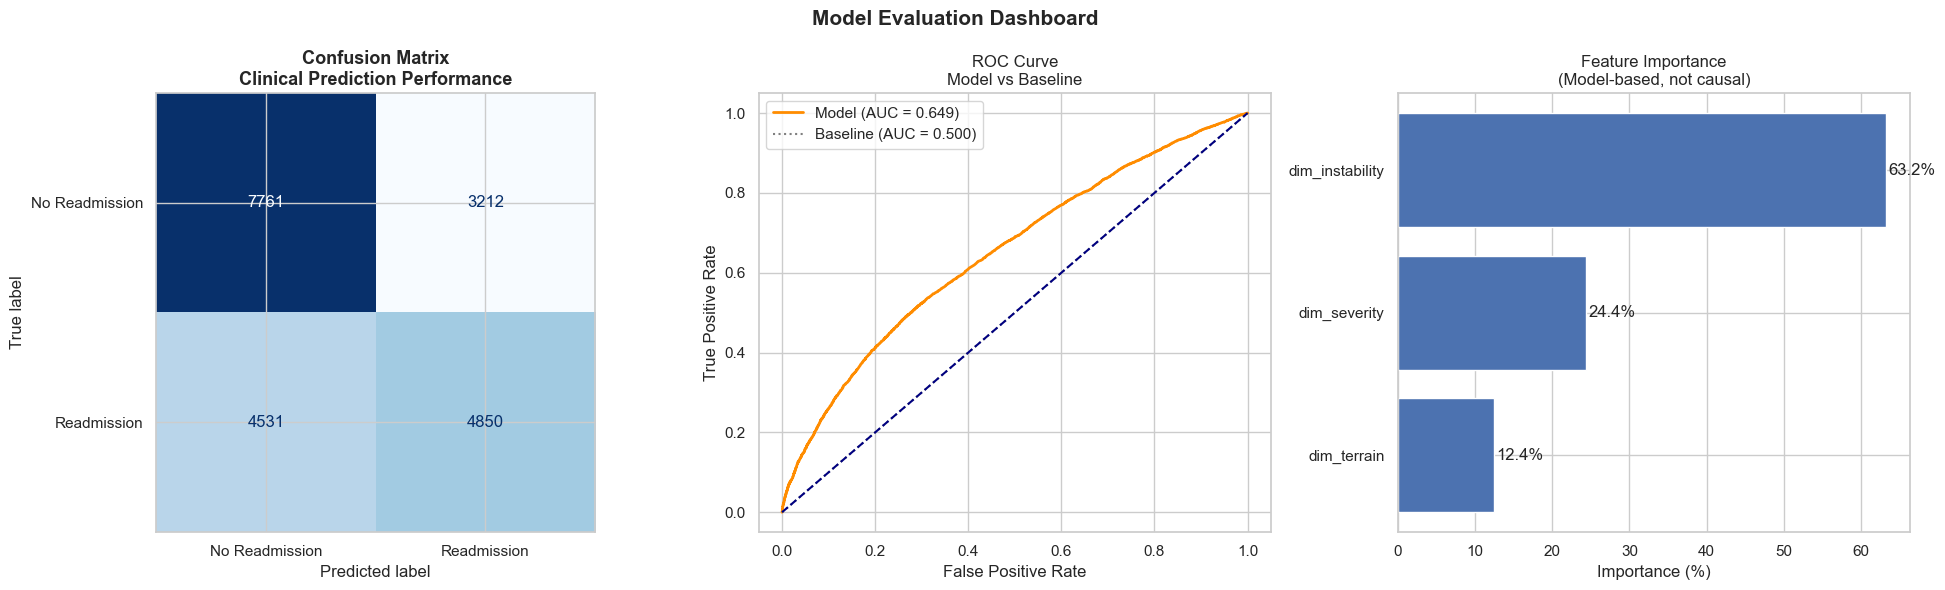

In [4]:
print("="*50)
print("MODEL EVALUATION DASHBOARD")
print("="*50)

y_pred = model.predict(X_test)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Readmission', 'Readmission']
)

disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(
    'Confusion Matrix\nClinical Prediction Performance',
    fontsize=13, fontweight='bold'
)

tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity (Recall)     : {sensitivity:.3f}")
print(f"Specificity              : {specificity:.3f}")
print(f"False Negatives (missed): {fn:,}")
print(f"False Positives (alerts): {fp:,}")

# --- Plot 2: ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, dummy_proba)

axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Model (AUC = {roc_auc:.3f})')

axes[1].plot(fpr_dummy, tpr_dummy, color='gray', lw=1.5, linestyle=':',
             label=f'Baseline (AUC = {dummy_auc:.3f})')

axes[1].plot([0, 1], [0, 1], linestyle='--', color='navy')

axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve\nModel vs Baseline')
axes[1].legend()

# --- Plot 3: Feature Importance ---
importances = model.feature_importances_

df_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances * 100
}).sort_values('Importance')

axes[2].barh(df_imp['Feature'], df_imp['Importance'])

axes[2].set_xlabel('Importance (%)')
axes[2].set_title('Feature Importance\n(Model-based, not causal)')

for i, v in enumerate(df_imp['Importance']):
    axes[2].text(v + 0.3, i, f'{v:.1f}%', va='center')

plt.suptitle('Model Evaluation Dashboard', fontsize=15, fontweight='bold')
plt.tight_layout()

plt.savefig(
    os.path.join(PLOT_DIR, "model_evaluation_dashboard.png"),
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [5]:
# --- Save trained model ---
MODEL_DIR = r"..\models"
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, os.path.join(MODEL_DIR, "readmission_model.pkl"))
print(f"✅ Model saved → {MODEL_DIR}\\readmission_model.pkl")

✅ Model saved → ..\models\readmission_model.pkl


# Phase 10 — Conclusion & Discussion

## 10.1 Key Findings

30-day hospital readmission in diabetic patients can be predicted with moderate performance
(ROC-AUC ≈ 0.64) using only three clinically interpretable composite dimensions derived from
administrative data — clearly outperforming a non-informative baseline (AUC ≈ 0.50).

**Chronic Instability** (prior hospital and emergency admissions) emerges as the strongest
predictor, consistent with established clinical evidence linking prior healthcare utilisation
to increased readmission risk.

---

## 10.2 Methodological Insights

- **Expert-driven dimensionality reduction** was preferred over PCA to preserve clinical meaning
- **Strict train/test discipline** — all preprocessing steps performed on training set only, ensuring no data leakage
- **MinMax scaling** guarantees comparability across dimensions
- **Correlation-based weighting** used as a pragmatic signal-strength heuristic
- **Class imbalance** handled via `class_weight='balanced'`, avoiding synthetic data generation

---

## 10.3 Limitations

- Model relies exclusively on a limited set of administrative numeric variables
- Pearson correlation captures only linear associations, potentially missing non-linear effects
- No external validation cohort available, limiting generalisability

---

## 10.4 Perspectives

- Incorporating additional categorical variables through encoding strategies
- Testing gradient boosting models (XGBoost / LightGBM)
- Evaluating feature stability via internal consistency measures (e.g., Cronbach's alpha)
- Applying SHAP analysis for patient-level interpretability